# Trabajo Práctico N°3 — Aprendizaje No Supervisado
## Segmentación de clientes con K-Means

**Agustín Musanti** · Certificación Avanzada en Data Science (ITBA)

---

Versión en Python del TP de aprendizaje no supervisado, aplicada a un caso de negocio donde se busca segmentar la base de clientes de un shopping para identificar perfiles de consumo accionables (a quién retener, a quién incentivar, etc).

**Dataset:** *Mall Customer Segmentation Data*. Dataset público de práctica. 
Fuente:`https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python`. El CSV se incluye junto al notebook.

**Variables:**
- `CustomerID`: identificador único del cliente.
- `Gender`: género.
- `Age`: edad.
- `Annual_Income (k$)`: ingreso anual estimado, en miles de dólares.
- `Spending_Score (1-100)`: puntaje de gasto/fidelidad asignado por el shopping según comportamiento de compra (a mayor puntaje, más consume).

Para el clustering uso **Annual Income** y **Spending Score**, las dos variables que definen el valor comercial del cliente.

### 1) Carga del dataset y exploración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")
df.columns = df.columns.str.strip()
df = df.rename(columns={
    "Genre": "Gender",
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score"
})

print("Dimensiones:", df.shape)
print("Valores nulos:", df.isnull().sum().sum())
df.head()

Dimensiones: (200, 5)
Valores nulos: 0


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 2) Resumen estadístico de la base

In [12]:
df.drop(columns="Cluster").describe().round(2)

,CustomerID,Age,Annual_Income,Spending_Score
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


### 3) Preprocesamiento: selección de variables y escalado

Selecciono las dos variables de negocio y las estandarizo (`StandardScaler`).
En K-Means el algoritmo usa distancias euclídeas, por lo que si dejo las variables en su escala original, la de mayor rango pesaría de más. Escalando, ambas contribuyen por igual al armado de los grupos.

In [2]:
X = df[["Annual_Income", "Spending_Score"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Media post-escalado:", X_scaled.mean(axis=0).round(3))
print("Desvío post-escalado:", X_scaled.std(axis=0).round(3))

Media post-escalado: [-0. -0.]
Desvío post-escalado: [1. 1.]


### 4) Elección de k: método del codo y silhouette

Busco justificar la cantidad de grupos con dos métricas:
- **Inercia (codo):** suma de distancias al cuadrado dentro de cada cluster. La idea es buscar el "codo" donde sumar grupos deja de aportar.
- **Silhouette:** mide qué tan bien separados están los clusters (-1 a 1, más alto = mejor).

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

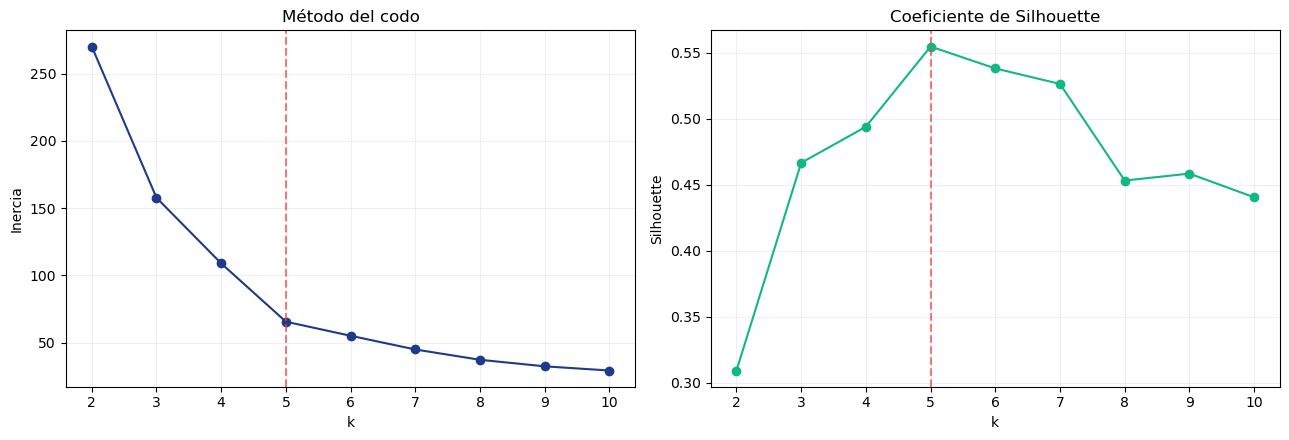

Silhouette por k: {2: 0.309, 3: 0.467, 4: 0.494, 5: 0.555, 6: 0.538, 7: 0.526, 8: 0.453, 9: 0.458, 10: 0.44}


In [4]:
inercias, silhouettes, ks = [], [], range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ks, inercias, "o-", color="#1E3A8A")
ax[0].axvline(5, ls="--", color="#EF4444", alpha=0.7)
ax[0].set_title("Método del codo"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inercia")
ax[0].grid(alpha=0.2)
ax[1].plot(ks, silhouettes, "o-", color="#10B981")
ax[1].axvline(5, ls="--", color="#EF4444", alpha=0.7)
ax[1].set_title("Coeficiente de Silhouette"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette")
ax[1].grid(alpha=0.2)
plt.tight_layout(); plt.show()

print("Silhouette por k:", {k: round(s, 3) for k, s in zip(ks, silhouettes)})

El codo se marca en **k=5** y el silhouette alcanza su máximo (≈0.55) también en **k=5**. Ambas coinciden.

### 5) K-Means con k=5

In [5]:
# Uso 123 como semilla
kmeans = KMeans(n_clusters=5, random_state=123, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Modelo entrenado. Clusters asignados a las", len(df), "observaciones.")

Modelo entrenado. Clusters asignados a las 200 observaciones.


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### 6) ¿Cuántos elementos quedaron en cada grupo?

In [6]:
tamaños = df["Cluster"].value_counts().sort_index()
print(tamaños)
print("\nTotal:", tamaños.sum())

Cluster
0    39
1    81
2    35
3    22
4    23
Name: count, dtype: int64

Total: 200


### 7) Asignación de cada cliente a su grupo

In [7]:
print("Cluster asignado a cada cliente:")
print(df["Cluster"].values)

print("\nEl último cliente de la base pertenece al grupo:", df["Cluster"].iloc[-1])
df[["CustomerID", "Annual_Income", "Spending_Score", "Cluster"]].tail()

Cluster asignado a cada cliente:
[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 1 0 2 0 2 0 1 0 2 0 2 0 2 0 2 0 1 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2
 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0]

El último cliente de la base pertenece al grupo: 0


,CustomerID,Annual_Income,Spending_Score,Cluster
195,196,120,79,0
196,197,126,28,2
197,198,126,74,0
198,199,137,18,2
199,200,137,83,0


### 8) Centroides de cada grupo

Los centroides salen del modelo en escala estandarizada; los devuelvo a su escala original con `inverse_transform` para interpretarlos en dólares y puntaje.

In [8]:
centroides = scaler.inverse_transform(kmeans.cluster_centers_)
centroides_df = pd.DataFrame(centroides, columns=["Annual_Income", "Spending_Score"]).round(2)
centroides_df.index.name = "Cluster"
centroides_df

,Annual_Income,Spending_Score
Cluster,,
0,86.54,82.13
1,55.30,49.52
2,88.20,17.11
3,25.73,79.36
4,26.30,20.91


### 9) Perfilado de los segmentos

Cruzo los centroides con la edad promedio. La lectura de cada grupo se hace en la conclusión, a partir de su perfil de ingreso y gasto.

In [13]:
perfil = df.groupby("Cluster").agg(
    n_clientes=("CustomerID", "count"),
    edad_prom=("Age", "mean"),
    ingreso_prom=("Annual_Income", "mean"),
    spending_prom=("Spending_Score", "mean")
).round(1)
perfil

,n_clientes,edad_prom,ingreso_prom,spending_prom
Cluster,,,,
0,39,32.7,86.5,82.1
1,81,42.7,55.3,49.5
2,35,41.1,88.2,17.1
3,22,25.3,25.7,79.4
4,23,45.2,26.3,20.9


### 10) Visualización de los grupos

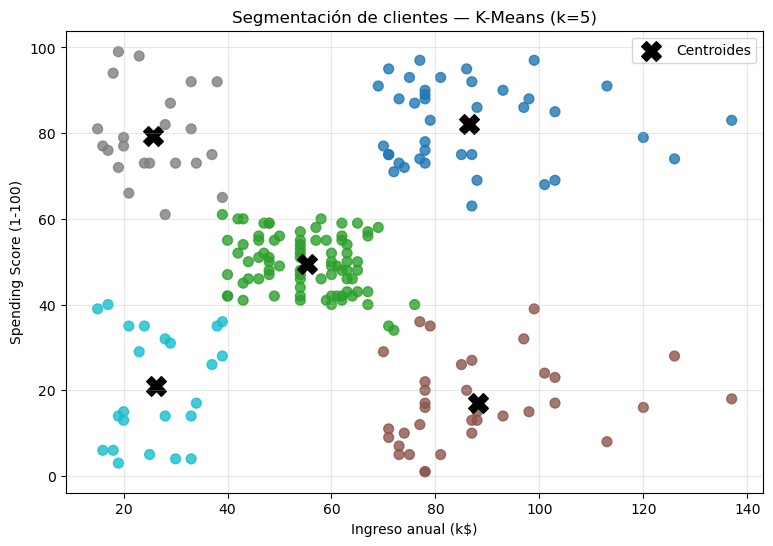

In [15]:
plt.figure(figsize=(9, 6))

# Puntos coloreados por cluster usando un colormap
plt.scatter(df["Annual_Income"], df["Spending_Score"],
            c=df["Cluster"], cmap="tab10", s=50, alpha=0.8)

# Centroides
plt.scatter(centroides[:, 0], centroides[:, 1],
            c="black", marker="X", s=200, label="Centroides")

plt.xlabel("Ingreso anual (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Segmentación de clientes — K-Means (k=5)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 11) Conclusión

K-Means permitió segmentar la base en 5 grupos con diferencias claras en ingreso y gasto, lo que facilita pensar acciones específicas para cada perfil.
Esta cantidad de grupos (k=5) se eligió con el método del codo y el coeficiente de silhouette.

El grupo más relevante es el de **alto ingreso y bajo gasto**, ya que concentra el mayor potencial de crecimiento, ya que son clientes con capacidad de compra que hoy no están siendo aprovechados. El techo de gasto ya existe, falta el incentivo, por lo que activarlos (incluso parcialmente) puede generar un impacto significativo.

Por otro lado, los clientes de **alto gasto y bajo ingreso** muestran un patrón de consumo elevado en relación a su nivel de ingreso, mientras que el grupo intermedio funciona como base estable.

En síntesis, la segmentación permite enfocar los esfuerzos comerciales activando a quienes tienen potencial y sostener al resto según su perfil.